In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
from operator import add
from typing import Annotated
class UpdatedGraphState(TypedDict):
    messages: Annotated[str,add]

In [3]:
def node_a(state: UpdatedGraphState) -> UpdatedGraphState:
    state['messages'] = "Im in Node A "
    return state

def node_b(state: UpdatedGraphState) -> UpdatedGraphState:
    state['messages'] = "Im in Node B " 
    return state

def node_c(state: UpdatedGraphState) -> UpdatedGraphState:
    state['messages'] = "Im in Node C "
    return state

In [4]:
graph_builder = StateGraph(UpdatedGraphState)
graph_builder.set_entry_point("A")
graph_builder.add_node("A", node_a )
graph_builder.add_node("B", node_b )
graph_builder.add_node("C", node_c )
graph_builder.add_edge("A", "B")
graph_builder.add_edge("A", "C")
graph_builder.set_finish_point("B")
graph_builder.set_finish_point("C")
graph = graph_builder.compile()

In [6]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display

def draw_graph(graph: CompiledStateGraph):
    display(Image(graph.get_graph().draw_mermaid_png()))




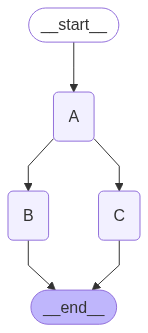

In [7]:
draw_graph(graph)


In [8]:
result = graph.invoke({"messages": ""})
print(result)


{'messages': 'Im in Node A Im in Node B Im in Node C '}


In [9]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, AnyMessage
from langgraph.graph import add_messages


In [10]:
messages = []


In [11]:
messages = add_messages(messages,[HumanMessage("How are you")])


In [12]:
messages


[HumanMessage(content='How are you', additional_kwargs={}, response_metadata={}, id='f66de18d-8c7a-49fc-82b9-7415c202b621')]

In [13]:
messages = add_messages(messages,[HumanMessage("What are you"), AIMessage("Im an LLM"), HumanMessage("What is LLM?")])


In [14]:
messages


[HumanMessage(content='How are you', additional_kwargs={}, response_metadata={}, id='f66de18d-8c7a-49fc-82b9-7415c202b621'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='3b69080f-416a-4fd6-a1b7-1a3b8dc1e1b0'),
 AIMessage(content='Im an LLM', additional_kwargs={}, response_metadata={}, id='b5fb499f-312c-4a5f-9dba-a49e8c7b6fe0'),
 HumanMessage(content='What is LLM?', additional_kwargs={}, response_metadata={}, id='9a5be721-aefc-4d28-a446-7aa3ec1194d4')]

In [15]:
my_message = SystemMessage("You are an helpful assitant")
my_message

SystemMessage(content='You are an helpful assitant', additional_kwargs={}, response_metadata={})

In [16]:
messages = add_messages(messages,[my_message])
messages

[HumanMessage(content='How are you', additional_kwargs={}, response_metadata={}, id='f66de18d-8c7a-49fc-82b9-7415c202b621'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='3b69080f-416a-4fd6-a1b7-1a3b8dc1e1b0'),
 AIMessage(content='Im an LLM', additional_kwargs={}, response_metadata={}, id='b5fb499f-312c-4a5f-9dba-a49e8c7b6fe0'),
 HumanMessage(content='What is LLM?', additional_kwargs={}, response_metadata={}, id='9a5be721-aefc-4d28-a446-7aa3ec1194d4'),
 SystemMessage(content='You are an helpful assitant', additional_kwargs={}, response_metadata={}, id='718f4149-38d5-4bc2-9af3-8a545614c41d')]

In [ ]:
class MessageUpdateState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    

In [18]:
def node_a(state: MessageUpdateState) -> MessageUpdateState:
    state['messages'] = HumanMessage('Who are you')
    return state

In [19]:
def node_b(state: MessageUpdateState) -> MessageUpdateState:
    state['messages'] = HumanMessage('Why are you')
    return state

In [20]:
def node_c(state: MessageUpdateState) -> MessageUpdateState:
    state['messages'] = HumanMessage('What are you')
    return state

In [21]:
message_graph_builder = StateGraph(MessageUpdateState)
message_graph_builder.add_node("A", node_a)
message_graph_builder.add_node("B", node_b)
message_graph_builder.add_node("C", node_c)
message_graph_builder.add_edge(START, "A")
message_graph_builder.add_edge(START, "B")
message_graph_builder.add_edge(START, "C")
message_graph_builder.set_finish_point("A")
message_graph_builder.set_finish_point("B")
message_graph_builder.set_finish_point("C")
message_graph = message_graph_builder.compile()

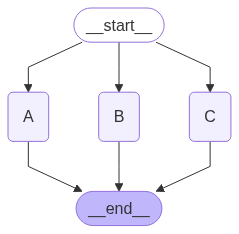

In [22]:
draw_graph(message_graph)


In [23]:
result = message_graph.invoke({"messages": []})
result

{'messages': [HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='1829ea1c-f061-46ed-816a-8d6e1366af65'),
  HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='4573c796-3c01-467f-b36e-e133c24ce3b5'),
  HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='79530259-62e0-4a35-a203-05a3ad6b411b')]}

In [24]:
result['messages']


[HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='1829ea1c-f061-46ed-816a-8d6e1366af65'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='4573c796-3c01-467f-b36e-e133c24ce3b5'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='79530259-62e0-4a35-a203-05a3ad6b411b')]

In [25]:
result = message_graph.invoke({"messages": result['messages'] })


In [26]:
result['messages']


[HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='1829ea1c-f061-46ed-816a-8d6e1366af65'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='4573c796-3c01-467f-b36e-e133c24ce3b5'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='79530259-62e0-4a35-a203-05a3ad6b411b'),
 HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='0dbc5691-901f-4771-a05e-b189c787e65b'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='1f21bb4c-32c2-43ae-bbbd-039a0a493512'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='cc3c996e-3f00-466a-8b09-9b927aaa37ba')]

In [27]:
result = message_graph.invoke({"messages": result['messages'] })


In [28]:
result['messages']


[HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='1829ea1c-f061-46ed-816a-8d6e1366af65'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='4573c796-3c01-467f-b36e-e133c24ce3b5'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='79530259-62e0-4a35-a203-05a3ad6b411b'),
 HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='0dbc5691-901f-4771-a05e-b189c787e65b'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='1f21bb4c-32c2-43ae-bbbd-039a0a493512'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='cc3c996e-3f00-466a-8b09-9b927aaa37ba'),
 HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='9edc6ef8-1dc2-42a7-8361-d58fe5381ca6'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='fb1b3097-1ecf-40c8-ace5-17d5e52b04f3')

# Whatever we have done in above steps is already implemented as MessagesState


In [29]:
from langchain_core.messages import RemoveMessage


In [30]:
messages = result['messages']
messages

[HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='1829ea1c-f061-46ed-816a-8d6e1366af65'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='4573c796-3c01-467f-b36e-e133c24ce3b5'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='79530259-62e0-4a35-a203-05a3ad6b411b'),
 HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='0dbc5691-901f-4771-a05e-b189c787e65b'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='1f21bb4c-32c2-43ae-bbbd-039a0a493512'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='cc3c996e-3f00-466a-8b09-9b927aaa37ba'),
 HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='9edc6ef8-1dc2-42a7-8361-d58fe5381ca6'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='fb1b3097-1ecf-40c8-ace5-17d5e52b04f3')

In [31]:
all_ids = [message.id for message in result['messages']]
all_ids

['1829ea1c-f061-46ed-816a-8d6e1366af65',
 '4573c796-3c01-467f-b36e-e133c24ce3b5',
 '79530259-62e0-4a35-a203-05a3ad6b411b',
 '0dbc5691-901f-4771-a05e-b189c787e65b',
 '1f21bb4c-32c2-43ae-bbbd-039a0a493512',
 'cc3c996e-3f00-466a-8b09-9b927aaa37ba',
 '9edc6ef8-1dc2-42a7-8361-d58fe5381ca6',
 'fb1b3097-1ecf-40c8-ace5-17d5e52b04f3',
 '2d04aadd-4141-4465-81ed-94f81e4cc957']

In [ ]:
#1 option
deleted_ids = [message.id for message in result['messages'][:-3]]
deleted_ids

['1829ea1c-f061-46ed-816a-8d6e1366af65',
 '4573c796-3c01-467f-b36e-e133c24ce3b5',
 '79530259-62e0-4a35-a203-05a3ad6b411b',
 '0dbc5691-901f-4771-a05e-b189c787e65b',
 '1f21bb4c-32c2-43ae-bbbd-039a0a493512',
 'cc3c996e-3f00-466a-8b09-9b927aaa37ba']

In [33]:
#2 option
deleted_messages = [ RemoveMessage(id=message.id) for message in result['messages'][:-3] ]


In [34]:
deleted_messages

[RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1829ea1c-f061-46ed-816a-8d6e1366af65'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='4573c796-3c01-467f-b36e-e133c24ce3b5'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='79530259-62e0-4a35-a203-05a3ad6b411b'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='0dbc5691-901f-4771-a05e-b189c787e65b'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='1f21bb4c-32c2-43ae-bbbd-039a0a493512'),
 RemoveMessage(content='', additional_kwargs={}, response_metadata={}, id='cc3c996e-3f00-466a-8b09-9b927aaa37ba')]

In [35]:
messsages = add_messages(deleted_messages,result['messages'] )
messages

[HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='1829ea1c-f061-46ed-816a-8d6e1366af65'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='4573c796-3c01-467f-b36e-e133c24ce3b5'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='79530259-62e0-4a35-a203-05a3ad6b411b'),
 HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='0dbc5691-901f-4771-a05e-b189c787e65b'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='1f21bb4c-32c2-43ae-bbbd-039a0a493512'),
 HumanMessage(content='What are you', additional_kwargs={}, response_metadata={}, id='cc3c996e-3f00-466a-8b09-9b927aaa37ba'),
 HumanMessage(content='Who are you', additional_kwargs={}, response_metadata={}, id='9edc6ef8-1dc2-42a7-8361-d58fe5381ca6'),
 HumanMessage(content='Why are you', additional_kwargs={}, response_metadata={}, id='fb1b3097-1ecf-40c8-ace5-17d5e52b04f3')

In [36]:
def previous_n_messages(
        left: list[AnyMessage], 
        right: list[AnyMessage],
       ) -> list[AnyMessage]:
    if not isinstance(left, list):
        left = [left]
    if not isinstance(right, list):
        right = [right]

    all = left + right
    return all[-3:]

In [37]:
left_messages = [
    HumanMessage('Question 1'),
    HumanMessage('Question 2'),
    HumanMessage('Question 3'),
    HumanMessage('Question 4'),
]

right_messages = [
    HumanMessage('Question 5'),
]

In [38]:
previous_n_messages(left_messages, right_messages)


[HumanMessage(content='Question 3', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Question 4', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='Question 5', additional_kwargs={}, response_metadata={})]

In [ ]:
from langchain_core.messages import RemoveMessage
#1212221
#kjhnjvhndfghnsd